provide battlefield grid length, must be same for both players:  20
provide mode of operation: 0 if starting as server OR 1 if starting as client0
provide server ip to use:  127.0.0.1
provide server port to use:  8080
provide ship placement pattern, 0 for horizontal and 1 for vertical:  0
do you like your ship to be placed randomly? 1 for YES, 0 for No:  1


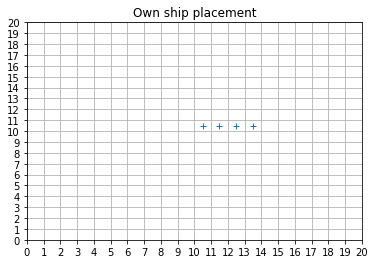

Ship of length 4 is deployed starting at pos X10,Y10 location
Server Waiting for connection

A Player has Connected

Received: outcome=NA, attempted_x_pos=3, attempted_y_pos=3
They Missed!
Guess Enemy ship cordinates: 
possible X axis location:  10
possible Y axis location:  10
Received: outcome=MISS, attempted_x_pos=11, attempted_y_pos=10


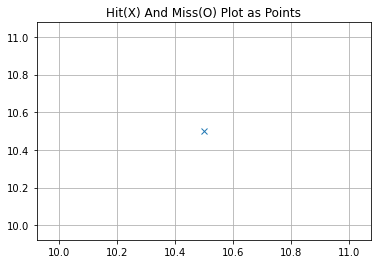

Got a Hit
Guess Enemy ship cordinates: 
possible X axis location:  10
possible Y axis location:  12


In [ ]:
#code to plot the hit/miss tries, this task will be executed whenever response arrives
import matplotlib.pyplot as plt
import numpy as np
import random

#needs argument which has data points like below

# "+" specifies own ship location
# "O" specifies point where enemy ship was HIT
# "X" specifies point where enemy ship was targeted but missed

hitsArray_X = []
hitsArray_Y = []
missArray_X = []
missArray_Y = []

middlePointPlacement = 0.5

shipLocation_X = []
shipLocation_Y = []

gridSize = 20 #default gridsize
step_size = 1 #default grid step

def setGridSize(gridSizeToPlot):
    gridSize = gridSizeToPlot

def updateHitList(ship_pos_x,ship_pos_y):
    global hitsArray_X
    global hitsArray_Y
    hitsArray_X.append(ship_pos_x+middlePointPlacement)
    hitsArray_Y.append(ship_pos_y+middlePointPlacement)
    #plotBattleGroundHitMissPlot(hitsArray_X, hitsArray_Y, missArray_X, missArray_Y)
    plotBattleGroundHitMissPlot()

def updateMissList(ship_pos_x,ship_pos_y):
    global missArray_X
    global missArray_Y
    missArray_X.append(ship_pos_x+middlePointPlacement)
    missArray_Y.append(ship_pos_y+middlePointPlacement)
    #plotBattleGroundHitMissPlot(hitsArray_X, hitsArray_Y, missArray_X, missArray_Y)
    plotBattleGroundHitMissPlot()

#def plotBattleGroundHitMissPlot(hitsArray_X, hitsArray_Y, missArray_X, missArray_Y):
def plotBattleGroundHitMissPlot():
    plt.clf()
    #plotEmptyBattleFieldGrid()
    if len(hitsArray_X) > 0 and len(hitsArray_Y) > 0 :
        plt.plot(hitsArray_X, hitsArray_Y, 'o')  # 'o' specifies circle markers
    if len(missArray_X) > 0 and len(missArray_Y) > 0 :
        plt.plot(missArray_X, missArray_Y, 'x')
    #plt.xlabel('x-axis')
    #plt.ylabel('y-axis')
    plt.grid(True)
    plt.title('Hit(X) And Miss(O) Plot as Points')
    plt.show()
    
def plotEmptyBattleFieldGrid():
    plt.xticks(np.arange(0, gridSize+step_size, step_size))
    plt.yticks(np.arange(0, gridSize+step_size, step_size))      
    plt.xlim(0, gridSize)
    plt.ylim(0, gridSize)
    #plt.plot(hitsArrayDefault_X, hitsArrayDefault_Y, 'x')  # 'o' specifies circle markers
    #plt.plot(missArrayDefault_X, missArrayDefault_Y, 'o')    
    #plt.grid(True)
    #plt.title('Hit(X) Vs Miss(O) Plot at Startup')
    #plt.show()
    
def deployShipAtUserDefinedLocation(ship_pos_x,ship_pos_y,isHorizontalPlacement,ship_length):
    #if ship_pos_x+ship_length > gridSize then just apply modulo and append to wrap around --to be done later

    if isHorizontalPlacement == 0: #i.e. horizontal placement
        for pos in range(ship_length):
            #only increase X, keep Y same
            shipLocation_X.append(ship_pos_x+pos+middlePointPlacement)
            shipLocation_Y.append(ship_pos_y+middlePointPlacement)
    else:    
        #vertical placement
        for pos in range(ship_length):
            #only increase X, keep Y same
            shipLocation_X.append(ship_pos_x+middlePointPlacement)
            shipLocation_Y.append(ship_pos_y+pos+middlePointPlacement)

    plotEmptyBattleFieldGrid()
    plt.plot(shipLocation_X, shipLocation_Y, '+')  # '+' specifies ship location
    plt.grid(True)
    plt.title('Own ship placement')
    plt.show()

#prefferred mode 
def deployShipAtAutoGeneratedLocation(isHorizontalPlacement,ship_length):
    ship_pos_x = random_integer = random.randint(0, gridSize-ship_length)
    ship_pos_y = ship_pos_x #taking same position
    deployShipAtUserDefinedLocation(ship_pos_x,ship_pos_y,isHorizontalPlacement,ship_length)
    return (ship_pos_x,ship_pos_y)  

def validateIncomingEnemyAttackPositions(attempted_x_pos, attempted_y_pos):
    #if attempted position lies within own's ship placement, return True to mark hit
    if (attempted_x_pos+middlePointPlacement in shipLocation_X) and (attempted_y_pos+middlePointPlacement in shipLocation_Y):
        print("Got a Hit")
        return True
    else:
        print("They Missed!")
        return False
    
import socket
import json
#from plotbattlefield import * 

#for testing purpose open two process with each functions and continue the game

def tcp_socket_client(dest_server_ip,dest_server_port, ship_length):

    client_sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)

    # Connect to the server
    #client_sock.connect(("192.168.0.2", 8080))
    client_sock.connect((dest_server_ip, dest_server_port))

    continueGame=True #until this player wins
    outcome = "NA"
    target_ship_pos_x=grid_size+1
    target_ship_pos_y=grid_size+1
    hitCounter = 0
    
    while continueGame:
        # Message to send to the server
        #Note only Client can make the first guess
        if continueGame == True:
            target_ship_pos_x,target_ship_pos_y = guessForEnemyShipLocation()
        
        '''
        # Send the message to the server
        hasShipSunk = True #of False --decides game continuation
        wasTargetHit = True #decide which list to populate
        '''

        dataToSend = createJSONPayloadToSend(outcome,target_ship_pos_x,target_ship_pos_y)

        client_sock.sendall(dataToSend.encode())
        
        #start blinking LED or buzzer --pending
        dataReceived = client_sock.recv(1024)
        
        outcome, received_x_pos, received_y_pos = decodeIncomingPayload(dataReceived)
        if isWinner(outcome):
            #we have won
            print("we have won according to server")
            updateHitList(target_ship_pos_x,target_ship_pos_y)
            continueGame = False
            break

        #if wasLastTryAHit(outcome):
        if outcome == "HIT":
            print(f"we have made an hit on last attempt according to server,last tried {target_ship_pos_x} {target_ship_pos_y}")
            #update hit list & redraw the grid
            updateHitList(target_ship_pos_x,target_ship_pos_y) # based on what we tried last, empty in this case
        elif outcome == "MISS":
            print(f"we have missed our on last attempt according to server,last tried {target_ship_pos_x} {target_ship_pos_y}")
            #update miss list & redraw the grid
            updateMissList(target_ship_pos_x,target_ship_pos_y)# based on what we tried last, empty in this case
            
        #time to cross validate  our ship location with enemy attack position to decide HIT or MISS
        hasEnemyAttackedSuccessFully = validateIncomingEnemyAttackPositions(received_x_pos, received_y_pos)
        if hasEnemyAttackedSuccessFully == True:
            #respond to enemy they have won
            outcome = "HIT" #or HIT
            hitCounter = hitCounter + 1
            
            if hitCounter == ship_length:
                outcome = "WIN"
                dataToSend = createJSONPayloadToSend(outcome,ship_pos_x,ship_pos_y)
                client_sock.sendall(dataToSend.encode())
                continueGame = False
                break
            else:
                outcome = "MISS"
            #other status like HIT or MISS will be sent along with user own guess
        '''
        #check what the other entity has responded?
        #is game over due to winning in response , mark continueGame as False
        # else 
        #is hit or miss
        #save ship_pos_x,ship_pos_y cordinate either in hit or miss category based on response
        #
        '''
    # Close the socket if there is a winner i.e. game is over
    client_sock.close()
    print("Client's Game Over")

def createJSONPayloadToSend(outcome,ship_pos_x,ship_pos_y):
        data_dict = {'outcome': outcome,'attempted_x_pos': ship_pos_x,'attempted_y_pos': ship_pos_y}
        data_string = json.dumps(data_dict) #convert json into string       
        return data_string

def isWinner(outcome):
    if outcome == "WON":
        return True
    else:
        return False
    
def wasLastTryAHit(outcome):
    if outcome == "HIT":
        return True
    else:
        return False   

def decodeIncomingPayload(data):
    message = data.decode()
    received_data = json.loads(message)
    #decodeIncomingPayload(data)
    
    outcome=received_data['outcome']
    attempted_x_pos=received_data['attempted_x_pos']
    attempted_y_pos=received_data['attempted_y_pos']
                     
    print(f"Received: outcome={outcome}, attempted_x_pos={attempted_x_pos}, attempted_y_pos={attempted_y_pos}")
    return (outcome,attempted_x_pos,attempted_y_pos)

def tcp_socket_server(server_ip,server_port, ship_length):
    
    server_sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)

    server_sock.bind((server_ip, server_port))
                     
    server_sock.listen()
                     
    print('Server Waiting for connection\n')
                     
    inConnHandle, clientAddr = server_sock.accept()
                     
    print('A Player has Connected\n')
                     
    continueGame=True #game will continue until this player is winner/loser 
    outcome = "NA"
    target_ship_pos_x=grid_size+1
    target_ship_pos_y=grid_size+1
    hitCounter = 0

    while continueGame:
                     
        #with inConnHandle:
                     
        dataReceived = inConnHandle.recv(1024)
                     
        outcome, received_x_pos, received_y_pos = decodeIncomingPayload(dataReceived)
                     
        if isWinner(outcome):
            #we have won as per other player, in this guess nothing needs to be sent
            continueGame = False
            break
        
        #other player said we didn't win, hence it send its own guess as well         
        if outcome == "HIT":
            #update hit list & redraw the grid
            updateHitList(target_ship_pos_x, target_ship_pos_y) # based on what we tried last, empty in this case
        elif outcome == "MISS":
            #update miss list & redraw the grid
            updateMissList(target_ship_pos_x, target_ship_pos_y)# based on what we tried last, empty in this case
            
        #time to cross validate  our ship location with enemy attack position to decide HIT or MISS
        hasEnemyAttackedSuccessFully = validateIncomingEnemyAttackPositions(received_x_pos, received_y_pos)
        if hasEnemyAttackedSuccessFully == True:
            #respond to enemy they have won
            outcome = "HIT" #or HIT
            hitCounter = hitCounter + 1
            if hitCounter == ship_length:
                outcome = "WIN"
                #only when other player has won, we dont need to guess again as game is going to finish
                continueGame = False
            else:
                target_ship_pos_x,target_ship_pos_y=guessForEnemyShipLocation() 
        else:
            outcome = "MISS"
            #also take own guess and send combined data
            target_ship_pos_x, target_ship_pos_y=guessForEnemyShipLocation()
            
        #winner, hit or miss we need to inform them because they are waiting for status
        dataToSend = createJSONPayloadToSend(outcome,target_ship_pos_x,target_ship_pos_y)
        inConnHandle.sendall(dataToSend.encode())

    # Close the socket if there is a winner i.e. game is over
    inConnHandle.close()
    server_sock.close()
    print("Server's Game Over")

def guessForEnemyShipLocation():
    print("Guess Enemy ship cordinates: ")
    ship_pos_x = int(input("possible X axis location:  "))
    ship_pos_y = int(input("possible Y axis location:  "))
    #ship_pos_x = input("possible X axis location:  ")
    #ship_pos_y = input("possible Y axis location:  ")
    return (ship_pos_x,ship_pos_y)

#import sys
#from plotbattlefield import * #anytime this file is changed the kernel needs restart
#from interpynqcomm import * 

#MODE=0 #mode=0 means server and mode=1 means client
#SERVER_IP='127.0.0.1' #change appropriately, only valid if mode is 1 i.e. process started in client mode
#SERVER_PORT=8080

'''
hitTriesAxis_X = []
hitTriesAxis_Y = []
missTriesAxis_X = []
missTriesAxis_Y = []
'''
SERVER = 0
CLIENT=1

grid_size = 20 #default grid size of 20x20 i.e 40 points
ship_length = int(grid_size*0.2)

if __name__ == "__main__":
    grid_size = int(input("provide battlefield grid length, must be same for both players:  ")) 
    setGridSize(grid_size)
    mode = int(input("provide mode of operation: 0 if starting as server OR 1 if starting as client"))

    if mode != SERVER:
        server_ip = input("provide destination server ip:  ")
        server_port = int(input("provide destination server port:  "))
    else:
        server_ip = input("provide server ip to use:  ")
        server_port = int(input("provide server port to use:  "))
        
    isHorizontalPlacement = int(input("provide ship placement pattern, 0 for horizontal and 1 for vertical:  "))
    is_ship_placement_random = int(input("do you like your ship to be placed randomly? 1 for YES, 0 for No:  "))
    if is_ship_placement_random:
        ship_pos_x,ship_pos_y=deployShipAtAutoGeneratedLocation(isHorizontalPlacement,ship_length)
        #print("Ship of length {} is deployed at pos[X,Y] {}{} ",format(ship_length,ship_pos_x,ship_pos_y))            
        print(f"Ship of length {ship_length} is deployed starting at pos X{ship_pos_x},Y{ship_pos_y} location")
    else:
        #ship_length = int(input("provide your ship length:  ")) #this should be less than grid size
        ship_pos_x = int(input("provide your ship's X axis start position:  "))
        ship_pos_y = int(input("provide your ship's Y axis start position:  "))
        print(f"Ship of length {ship_length} is to be deployed at pos X{ship_pos_x},Y{ship_pos_y} location")
        deployShipAtUserDefinedLocation(ship_pos_x,ship_pos_y,isHorizontalPlacement,ship_length)
        #take input positions of range 0..grid_size*grid_size-1
        #during connection setup we can verify whether players are opened in correct mode and have exact grid size

    #plotEmptyBattleFieldGrid(grid_size)
    #plotBattleGroundHitMissPlot(hitTriesAxis_X,hitTriesAxis_Y,missTriesAxis_X,missTriesAxis_Y)
    
    #now open socket & wait for other player to get connected
    #the LED will be displayed accordingly
    
    #enable wither server or client
    if mode == SERVER:
        tcp_socket_server(server_ip,server_port,ship_length)
    else:
        tcp_socket_client(server_ip,server_port,ship_length)